# Sprint 1 — Preprocessing & Data Preparation (Deliverable 1)

**Diabetes Prediction Project**  
Dataset: BRFSS 2015 — `diabetes_012_health_indicators_BRFSS2015.csv`

| Step | Description |
|------|-------------|
| 1 | Loading & initial understanding of the dataset |
| 2 | Separation between target variable and explanatory variables |
| 3 | Splitting the dataset (train/test) with stratify |
| 4 | Typing of variables |
| 5 | Cleaning of duplicates and handling of missing values |
| 6 | Quantitative exploratory analysis (Pearson, Levene, ANOVA) |
| 7 | Qualitative exploratory analysis (EDA visual) |
| 8 | Selection and implementation of a normalization method |
| 9 | Saving of the cleaned dataset |

## Imports & Configuration

In [ ]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
from scipy import stats

%matplotlib inline

# Configuration
DATA_PATH    = "diabetes_012_health_indicators_BRFSS2015.csv"
PLOTS_DIR    = ".\diagrams\deliverable1"
OUTPUT_DIR   = "output"
RANDOM_STATE = 42
TEST_SIZE    = 0.2

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("✅ Libraries loaded")

✅ Libraries loaded


---
## Step 1 — Loading & Initial Understanding of the Dataset

**Objective:** Import the raw dataset, identify key variables and data structure, and verify their consistency.

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"📐 Shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)")
print(f"\n📋 Columns ({df.shape[1]}):\n   {list(df.columns)}")
print(f"\n📑 Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

📐 Shape: (253680, 22)  (253,680 rows × 22 columns)

📋 Columns (22):
   ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

📑 Memory usage: 44.6 MB


In [ ]:
print("🔢 Data types:")
print(df.dtypes)

🔢 Data types:
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object


In [ ]:
df.head(10)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,2.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [ ]:
df.describe().round(2)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.0,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.3,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,...,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.7,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,...,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.0,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.0,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.0,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.0,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,...,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,2.0,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


In [ ]:
print("🎯 Original target distribution (Diabetes_012):")
target_counts = df["Diabetes_012"].value_counts().sort_index()
for label, cnt in target_counts.items():
    pct = cnt / len(df) * 100
    print(f"   Class {int(label)}: {cnt:>8,}  ({pct:.1f}%)")

🎯 Original target distribution (Diabetes_012):
   Class 0:  213,703  (84.2%)
   Class 1:    4,631  (1.8%)
   Class 2:   35,346  (13.9%)


---
## Step 2 — Separation Between Target Variable and Explanatory Variables

**Objective:** Identify the variable to be predicted (y) and the explanatory variables (X) for supervised modeling.

### 2a. Recode target (3-class → binary)

| Original | New Binary |
|----------|------------|
| 0 = no diabetes | 0 |
| 1 = prediabetes | 0 |
| 2 = diabetes | 1 |

In [ ]:
# Map: 0→0, 1→0, 2→1
df["Diabetes_binary"] = df["Diabetes_012"].map({0.0: 0, 1.0: 0, 2.0: 1})
df.drop(columns=["Diabetes_012"], inplace=True)

binary_counts = df["Diabetes_binary"].value_counts().sort_index()
for label, cnt in binary_counts.items():
    pct = cnt / len(df) * 100
    print(f"  Class {int(label)}: {cnt:>8,}  ({pct:.1f}%)")

imbalance_ratio = binary_counts[0] / binary_counts[1]
print(f"\n  ⚖️ Imbalance ratio (class 0 / class 1): {imbalance_ratio:.2f}")

  Class 0:  218,334  (86.1%)
  Class 1:   35,346  (13.9%)

  ⚖️ Imbalance ratio (class 0 / class 1): 6.18


### 2b. Explicit X / y separation

In [ ]:
y = df["Diabetes_binary"]
X = df.drop(columns=["Diabetes_binary"])

print(f"  Feature matrix X : {X.shape}  ({X.shape[1]} features)")
print(f"  Target vector  y : {y.shape}")
print(f"\n  Features: {list(X.columns)}")

  Feature matrix X : (253680, 21)  (21 features)
  Target vector  y : (253680,)

  Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


---
## Step 3 — Splitting the Dataset (Train / Test)

**Objective:** Create a training set and a test set while maintaining class balance.

**Methodological decision:** `train_test_split` with `stratify=y` to preserve the distribution of the target variable, especially in the context of imbalanced classes.

**Ethical justification:** Avoid skewing model performance during the testing phase → fairness and robustness.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y          # preserve class distribution
)

print(f"  Train set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"  Test  set: X_test  {X_test.shape},  y_test  {y_test.shape}")
print(f"\n  ✅ stratify=y ensures class balance is preserved:")
print(f"     Train — class 0: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%), "
      f"class 1: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"     Test  — class 0: {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%),  "
      f"class 1: {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")

  Train set: X_train (202944, 21), y_train (202944,)
  Test  set: X_test  (50736, 21),  y_test  (50736,)

  ✅ stratify=y ensures class balance is preserved:
     Train — class 0: 174,667 (86.1%), class 1: 28,277 (13.9%)
     Test  — class 0: 43,667 (86.1%),  class 1: 7,069 (13.9%)


---
## Step 4 — Typing of Variables

**Objective:** Check and adjust the types of each variable for optimal tractability.

**Action:** Explicit conversion of types (float, int, object, category). Detection of typing errors that could distort statistical analyses.

In [ ]:
print("Current data types before correction:")
print(X_train.dtypes.value_counts())

Current data types before correction:
float64    21
Name: count, dtype: int64


In [ ]:
# Classify columns semantically
binary_cols = [
    col for col in X_train.columns
    if sorted(X_train[col].dropna().unique().tolist()) == [0.0, 1.0]
]
ordinal_cols = [col for col in ["GenHlth", "Age", "Education", "Income"]
                if col in X_train.columns]
continuous_cols = [col for col in X_train.columns
                   if col not in binary_cols and col not in ordinal_cols]

print(f"  Binary (0/1) features ({len(binary_cols)}):")
print(f"    {binary_cols}")
print(f"\n  Ordinal features ({len(ordinal_cols)}):")
print(f"    {ordinal_cols}")
print(f"\n  Continuous features ({len(continuous_cols)}):")
print(f"    {continuous_cols}")

  Binary (0/1) features (14):
    ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

  Ordinal features (4):
    ['GenHlth', 'Age', 'Education', 'Income']

  Continuous features (3):
    ['BMI', 'MentHlth', 'PhysHlth']


In [ ]:
# Convert types for optimal memory + correctness
for col in binary_cols:
    X_train[col] = X_train[col].astype(np.int8)
    X_test[col]  = X_test[col].astype(np.int8)

for col in ordinal_cols:
    X_train[col] = X_train[col].astype(np.int32)
    X_test[col]  = X_test[col].astype(np.int32)

for col in continuous_cols:
    X_train[col] = X_train[col].astype(np.float64)
    X_test[col]  = X_test[col].astype(np.float64)

y_train = y_train.astype(np.int8)
y_test  = y_test.astype(np.int8)

print("✅ Data types after correction:")
print(X_train.dtypes)

✅ Data types after correction:
HighBP                     int8
HighChol                   int8
CholCheck                  int8
BMI                     float64
Smoker                     int8
Stroke                     int8
HeartDiseaseorAttack       int8
PhysActivity               int8
Fruits                     int8
Veggies                    int8
HvyAlcoholConsump          int8
AnyHealthcare              int8
NoDocbcCost                int8
GenHlth                   int32
MentHlth                float64
PhysHlth                float64
DiffWalk                   int8
Sex                        int8
Age                       int32
Education                 int32
Income                    int32
dtype: object


In [ ]:
# Check for typing anomalies
print("🔍 Checking for typing anomalies:")
anomalies_found = False

for col in binary_cols:
    unique_vals = sorted(X_train[col].unique().tolist())
    if unique_vals != [0, 1]:
        print(f"   ⚠️ {col} (expected [0,1], got {unique_vals})")
        anomalies_found = True

for col in ordinal_cols:
    unique_vals = sorted(X_train[col].unique().tolist())
    if any(v < 0 for v in unique_vals):
        print(f"   ⚠️ {col} has negative values: {unique_vals}")
        anomalies_found = True

if not anomalies_found:
    print("   ✅ No typing anomalies detected.")

🔍 Checking for typing anomalies:
   ✅ No typing anomalies detected.


---
## Step 5 — Cleaning of Duplicates and Handling of Missing Values

**Objective:** Improve the quality of the dataset.

**Action:** Removal of exact duplicates, analysis of missing-value proportion, imputation if needed.

In [ ]:
# 5a. Duplicates
n_before = len(X_train)
train_combined = pd.concat([X_train, y_train], axis=1)
dup_mask = train_combined.duplicated(keep="first")
n_dups = dup_mask.sum()

print(f"📋 Exact duplicates in training set: {n_dups:,} ({n_dups/n_before*100:.1f}%)")

if n_dups > 0:
    X_train = X_train[~dup_mask].reset_index(drop=True)
    y_train = y_train[~dup_mask].reset_index(drop=True)
    print(f"   → Removed {n_dups:,} duplicate rows")
    print(f"   → Training set: {len(X_train):,} rows (was {n_before:,})")
else:
    print("   → No duplicates to remove")

# Also check test set
test_combined = pd.concat([X_test, y_test], axis=1)
test_dups = test_combined.duplicated(keep="first").sum()
print(f"\n📋 Exact duplicates in test set: {test_dups:,}")

📋 Exact duplicates in training set: 17,498 (8.6%)
   → Removed 17,498 duplicate rows
   → Training set: 185,446 rows (was 202,944)

📋 Exact duplicates in test set: 2,023


In [ ]:
# 5b. Missing values
print("🔍 Missing values analysis:")
for name, data in [("X_train", X_train), ("X_test", X_test)]:
    missing = data.isna().sum()
    total_missing = missing.sum()
    if total_missing == 0:
        print(f"   {name}: ✅ No missing values")
    else:
        print(f"   {name}: ⚠️ {total_missing} missing values")
        for col in missing[missing > 0].index:
            pct = missing[col] / len(data) * 100
            print(f"     {col}: {missing[col]} ({pct:.2f}%)")
        # Impute: median for continuous, mode for categorical
        print(f"   → Imputing: median for continuous, mode for categorical")
        for col in missing[missing > 0].index:
            if col in continuous_cols:
                fill_val = data[col].median()
            else:
                fill_val = data[col].mode()[0]
            data[col].fillna(fill_val, inplace=True)

print(f"\n✅ Data quality summary after cleaning:")
print(f"   Training set: {len(X_train):,} rows, {X_train.isna().sum().sum()} missing values")
print(f"   Test set:     {len(X_test):,} rows, {X_test.isna().sum().sum()} missing values")

🔍 Missing values analysis:
   X_train: ✅ No missing values
   X_test: ✅ No missing values

✅ Data quality summary after cleaning:
   Training set: 185,446 rows, 0 missing values
   Test set:     50,736 rows, 0 missing values


---
## Step 6 — Quantitative Exploratory Analysis

**Objective:** Identify statistical relationships between variables.

**Methods used:**
- Pearson's test for linear correlations (continuous variables)
- Levene's test to check for homogeneity of variances
- ANOVA test for variance analysis between groups
- Correlation matrix for visualizing global dependencies

### 6a. Pearson Correlation Test

In [ ]:
print("📊 Pearson Correlation Test (features vs. target):")
print(f"{'Feature':<25s}  {'r':>8s}  {'p-value':>12s}  Significance")
print("-" * 65)

pearson_results = {}
test_cols = continuous_cols + ordinal_cols
for col in test_cols:
    r, p = stats.pearsonr(X_train[col], y_train)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    pearson_results[col] = {"r": r, "p": p, "sig": sig}
    print(f"{col:<25s}  {r:+.4f}  {p:>12.2e}  {sig}")

📊 Pearson Correlation Test (features vs. target):
Feature                           r       p-value  Significance
-----------------------------------------------------------------
BMI                        +0.2086      0.00e+00  ***
MentHlth                   +0.0561     3.29e-129  ***
PhysHlth                   +0.1584      0.00e+00  ***
GenHlth                    +0.2788      0.00e+00  ***
Age                        +0.1768      0.00e+00  ***
Education                  -0.1036      0.00e+00  ***
Income                     -0.1429      0.00e+00  ***


### 6b. Levene's Test (Homogeneity of Variances)

In [ ]:
print("📊 Levene's Test (homogeneity of variances between classes):")
print(f"{'Feature':<25s}  {'W-stat':>10s}  {'p-value':>12s}  Homogeneous?")
print("-" * 65)

levene_results = {}
for col in test_cols:
    group0 = X_train.loc[y_train == 0, col]
    group1 = X_train.loc[y_train == 1, col]
    stat_val, p = stats.levene(group0, group1)
    homo = "Yes" if p >= 0.05 else "No"
    levene_results[col] = {"W": stat_val, "p": p, "homogeneous": homo}
    print(f"{col:<25s}  {stat_val:>10.2f}  {p:>12.2e}  {homo}")

📊 Levene's Test (homogeneity of variances between classes):
Feature                        W-stat       p-value  Homogeneous?
-----------------------------------------------------------------
BMI                            859.89     1.40e-188  No
MentHlth                       585.79     3.29e-129  No
PhysHlth                      4749.73      0.00e+00  No
GenHlth                         59.08      1.52e-14  No
Age                           3875.36      0.00e+00  No
Education                      280.83      5.50e-63  No
Income                         687.14     3.54e-151  No


### 6c. One-Way ANOVA

In [ ]:
print("📊 One-Way ANOVA (variance between diabetes groups):")
print(f"{'Feature':<25s}  {'F-stat':>10s}  {'p-value':>12s}  Significant?")
print("-" * 65)

anova_results = {}
for col in test_cols:
    group0 = X_train.loc[y_train == 0, col]
    group1 = X_train.loc[y_train == 1, col]
    f_stat, p = stats.f_oneway(group0, group1)
    sig = "Yes (p<0.05)" if p < 0.05 else "No"
    anova_results[col] = {"F": f_stat, "p": p, "sig": sig}
    print(f"{col:<25s}  {f_stat:>10.2f}  {p:>12.2e}  {sig}")

📊 One-Way ANOVA (variance between diabetes groups):
Feature                        F-stat       p-value  Significant?
-----------------------------------------------------------------
BMI                           8433.50      0.00e+00  Yes (p<0.05)
MentHlth                       585.79     3.29e-129  Yes (p<0.05)
PhysHlth                      4775.34      0.00e+00  Yes (p<0.05)
GenHlth                      15628.19      0.00e+00  Yes (p<0.05)
Age                           5985.50      0.00e+00  Yes (p<0.05)
Education                     2011.76      0.00e+00  Yes (p<0.05)
Income                        3865.36      0.00e+00  Yes (p<0.05)


### 6d. Correlation Matrix & Top Correlations with Target

In [ ]:
train_full = pd.concat([X_train, y_train.rename("Diabetes_binary")], axis=1)
corr = train_full.corr()

print("🔗 Top 10 correlations with Diabetes_binary:")
target_corr = corr["Diabetes_binary"].drop("Diabetes_binary").abs().sort_values(ascending=False)
for feat, val in target_corr.head(10).items():
    sign = "+" if corr.loc[feat, "Diabetes_binary"] > 0 else "−"
    print(f"   {sign} {feat:<25s}  {corr.loc[feat, 'Diabetes_binary']:+.3f}")

🔗 Top 10 correlations with Diabetes_binary:
   + GenHlth                    +0.279
   + HighBP                     +0.255
   + BMI                        +0.209
   + DiffWalk                   +0.208
   + HighChol                   +0.196
   + Age                        +0.177
   + HeartDiseaseorAttack       +0.170
   + PhysHlth                   +0.158
   − Income                     -0.143
   − Education                  -0.104


---
## Step 7 — Qualitative Exploratory Analysis (EDA Visual)

**Objective:** Identify trends and anomalies through visualization.

**Action:** Relevant graphical representations: histograms, boxplots, heatmaps, barplots.

**Justification:** Support for transparency and communication of results, including to non-technical parties.

### 7a. Correlation Heatmap

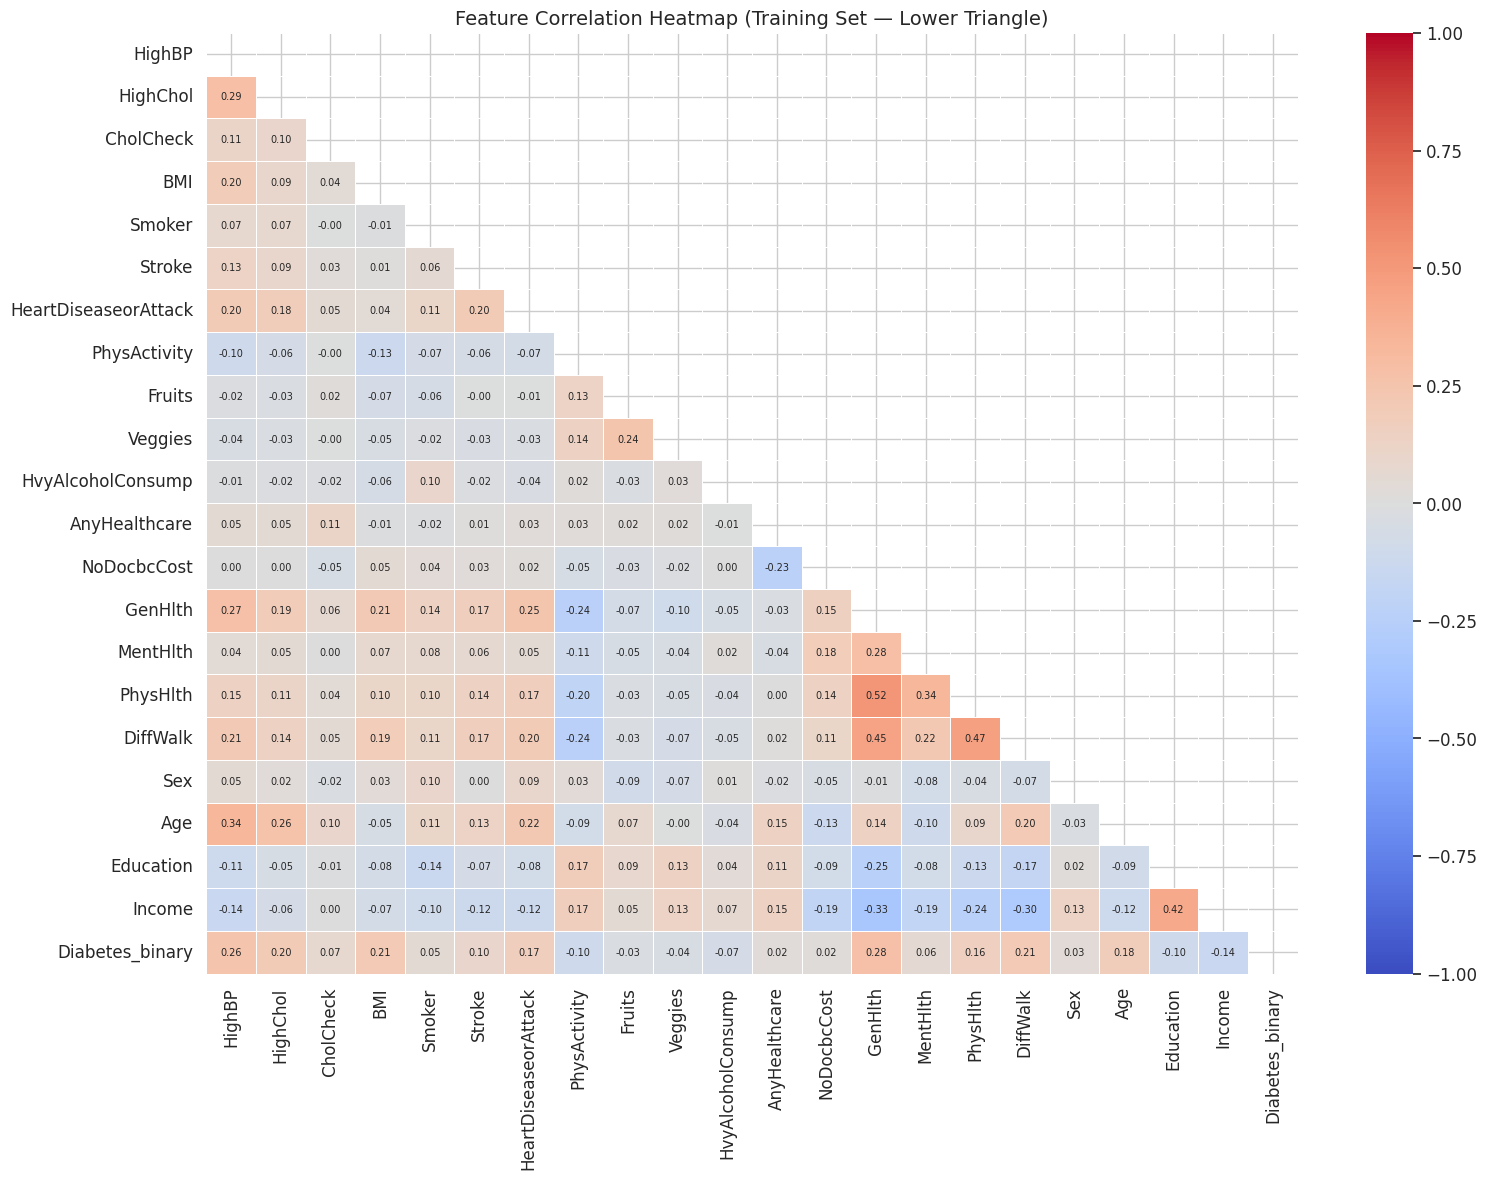

In [ ]:
fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, ax=ax, vmin=-1, vmax=1, center=0,
    annot_kws={"size": 7}
)
ax.set_title("Feature Correlation Heatmap (Training Set — Lower Triangle)", fontsize=14)
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "correlation_heatmap.png"), dpi=150)
plt.show()

### 7b. Target Distribution

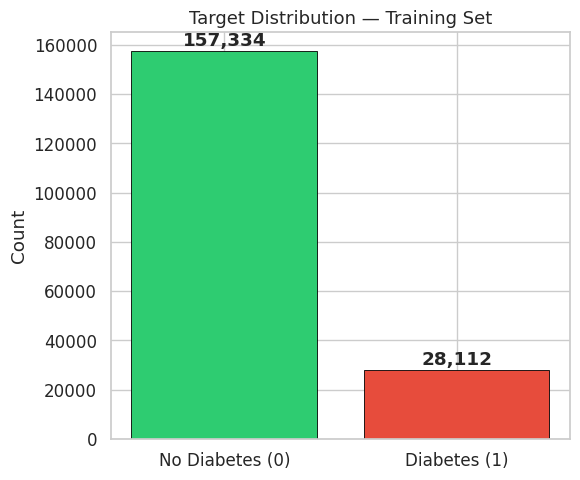

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#2ecc71", "#e74c3c"]
train_target_counts = y_train.value_counts().sort_index()
bars = ax.bar(
    ["No Diabetes (0)", "Diabetes (1)"],
    train_target_counts.values,
    color=colors, edgecolor="black", linewidth=0.6
)
for bar, cnt in zip(bars, train_target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
        f"{cnt:,}", ha="center", va="bottom", fontweight="bold"
    )
ax.set_title("Target Distribution — Training Set", fontsize=13)
ax.set_ylabel("Count")
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "target_distribution.png"), dpi=150)
plt.show()

### 7c. Feature Histograms

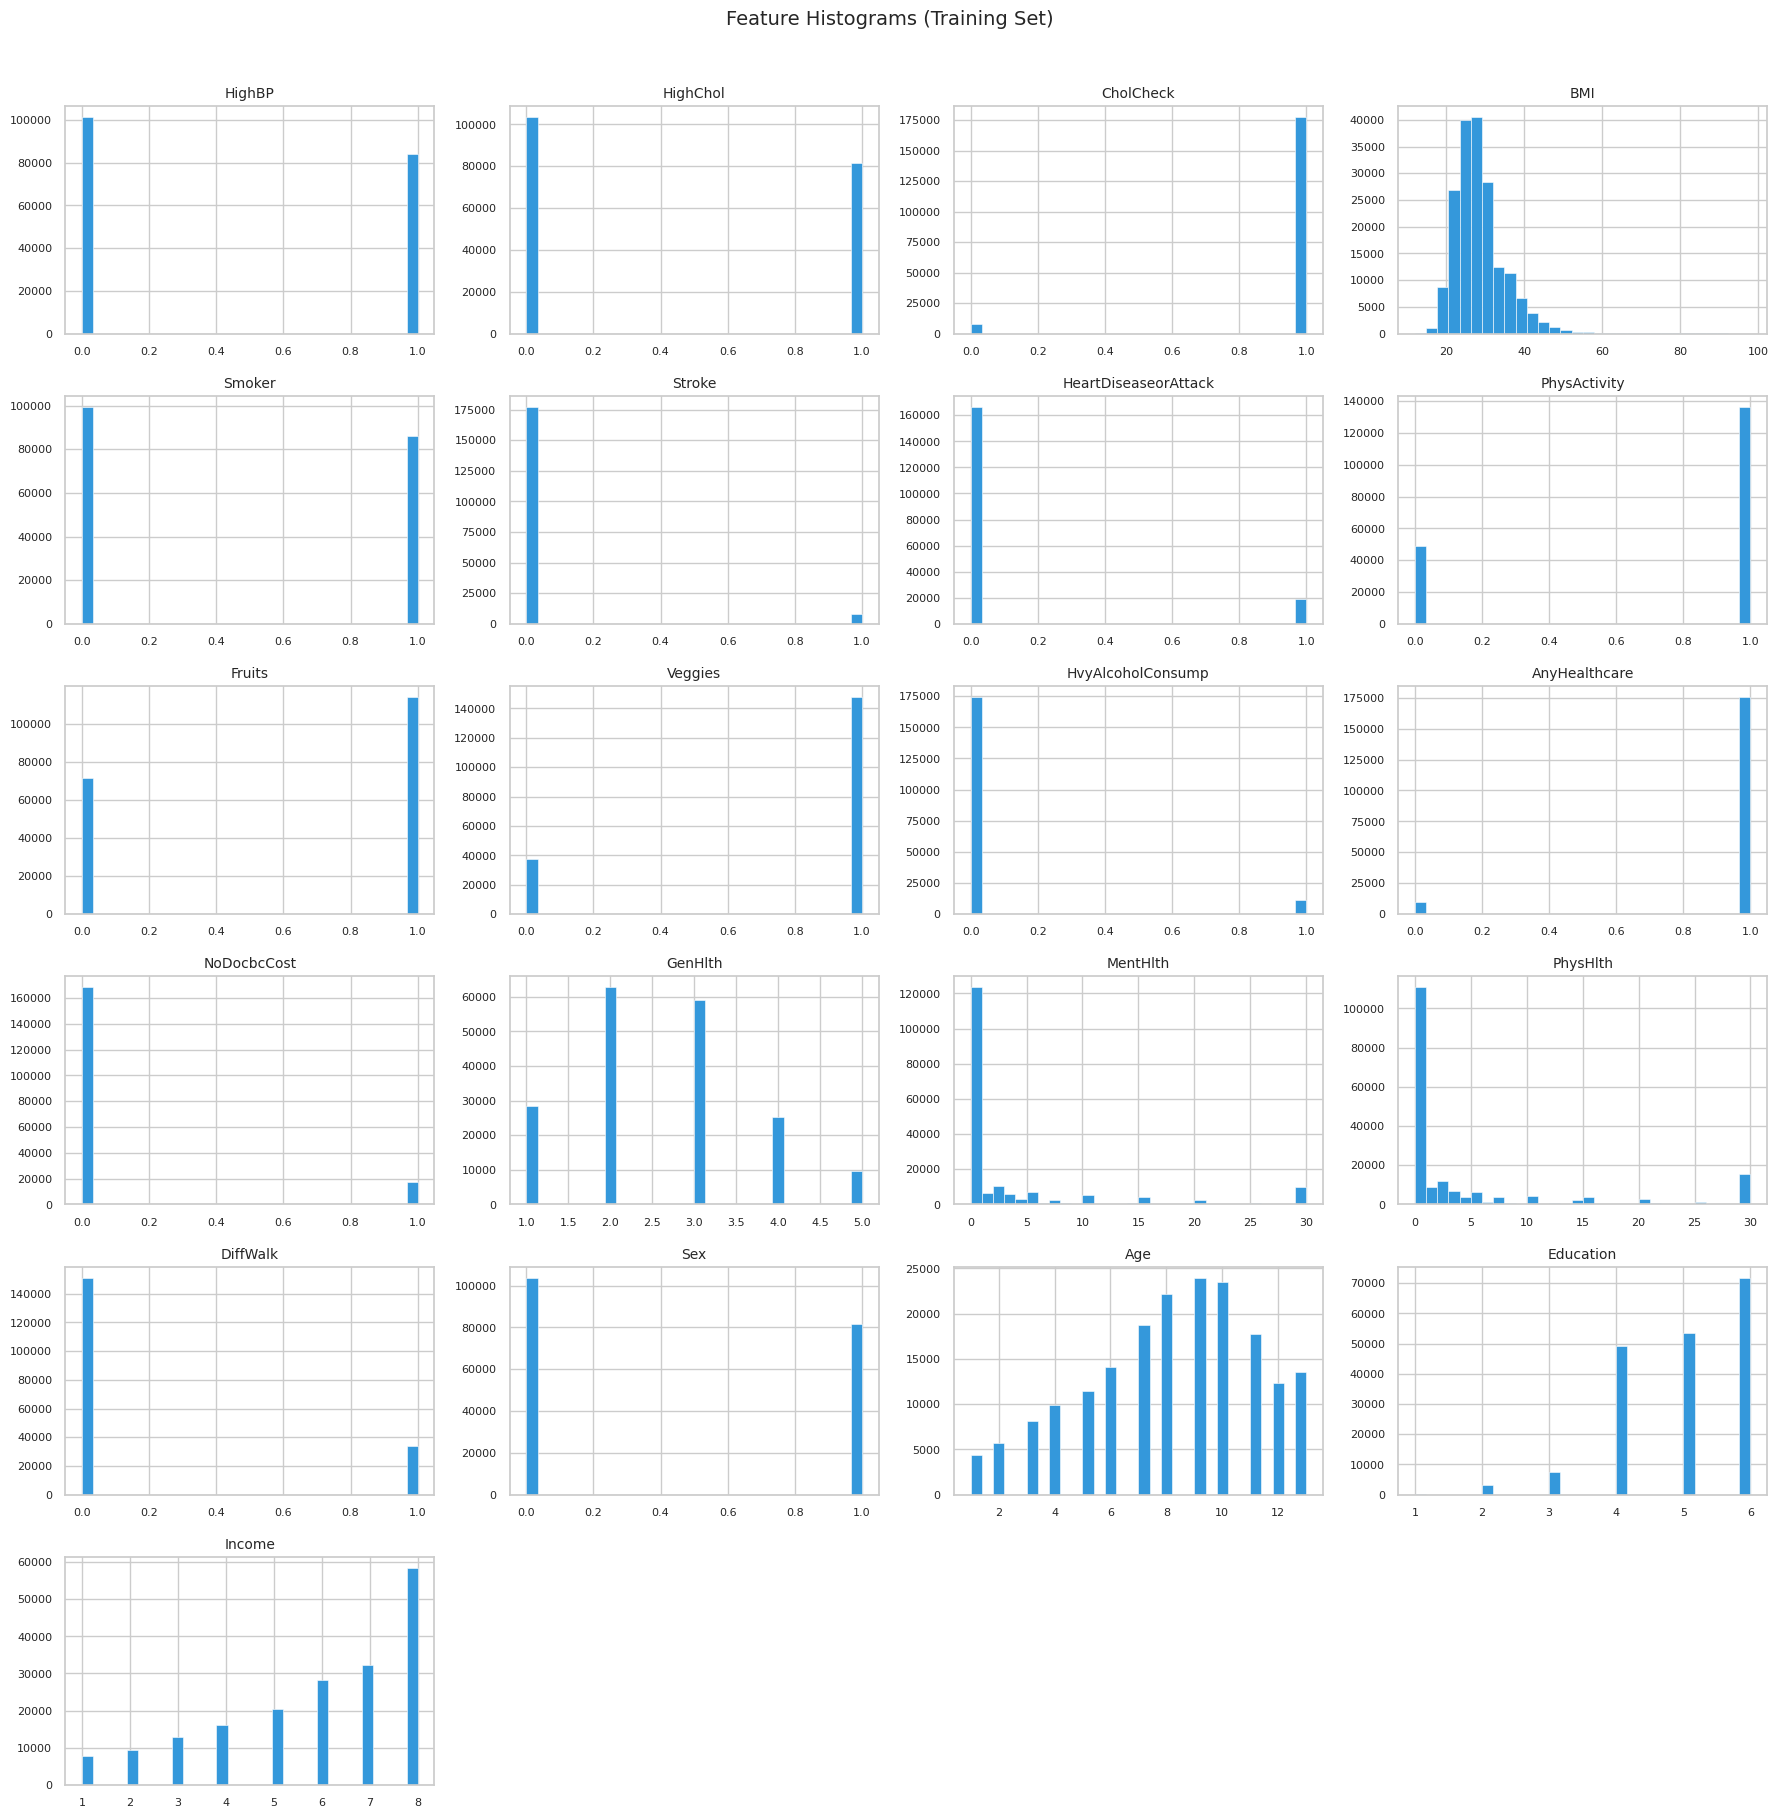

In [ ]:
n_features = X_train.shape[1]
n_cols_grid = 4
n_rows_grid = int(np.ceil(n_features / n_cols_grid))
fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 3 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(X_train.columns):
    X_train[col].hist(bins=30, ax=axes[i], color="#3498db", edgecolor="white", linewidth=0.4)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Histograms (Training Set)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "feature_histograms.png"), dpi=150)
plt.show()

### 7d. Boxplots — Continuous & Ordinal Features by Diabetes Status

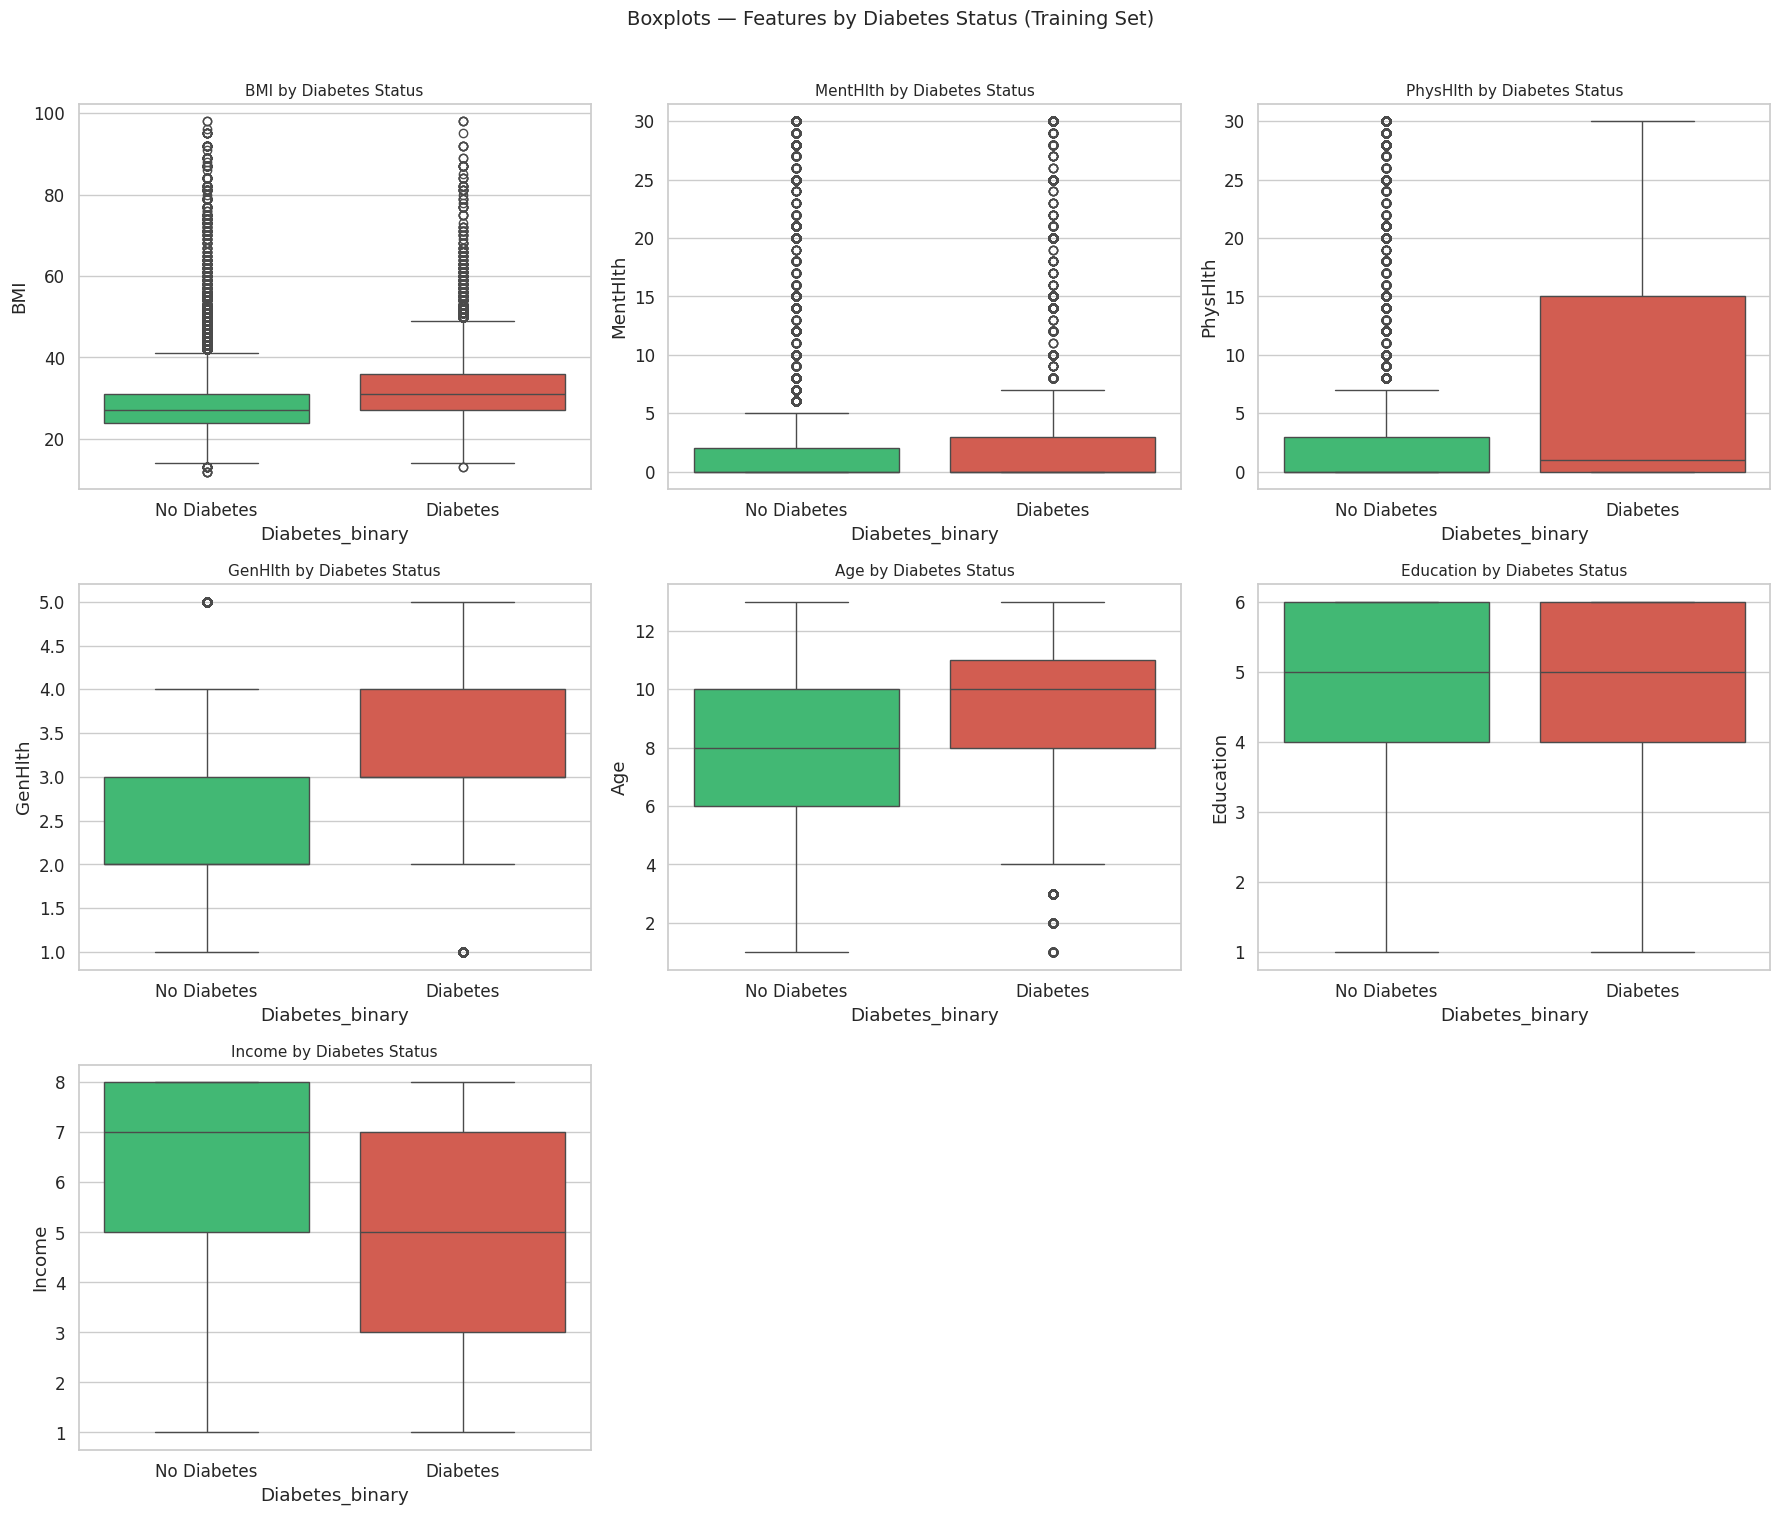

In [ ]:
box_features = continuous_cols + ordinal_cols
n_box = len(box_features)
n_cols_box = 3
n_rows_box = int(np.ceil(n_box / n_cols_box))

fig, axes = plt.subplots(n_rows_box, n_cols_box, figsize=(18, 5 * n_rows_box))
axes = axes.flatten()

train_plot_df = pd.concat([X_train, y_train.rename("Diabetes_binary")], axis=1)

for i, col in enumerate(box_features):
    sns.boxplot(
        data=train_plot_df, x="Diabetes_binary", y=col,
        hue="Diabetes_binary", palette={0: colors[0], 1: colors[1]},
        legend=False, ax=axes[i]
    )
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No Diabetes", "Diabetes"])
    axes[i].set_title(f"{col} by Diabetes Status", fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Boxplots — Features by Diabetes Status (Training Set)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "boxplots_by_class.png"), dpi=150)
plt.show()

### 7e. BMI Distribution — Violin + Box Plot

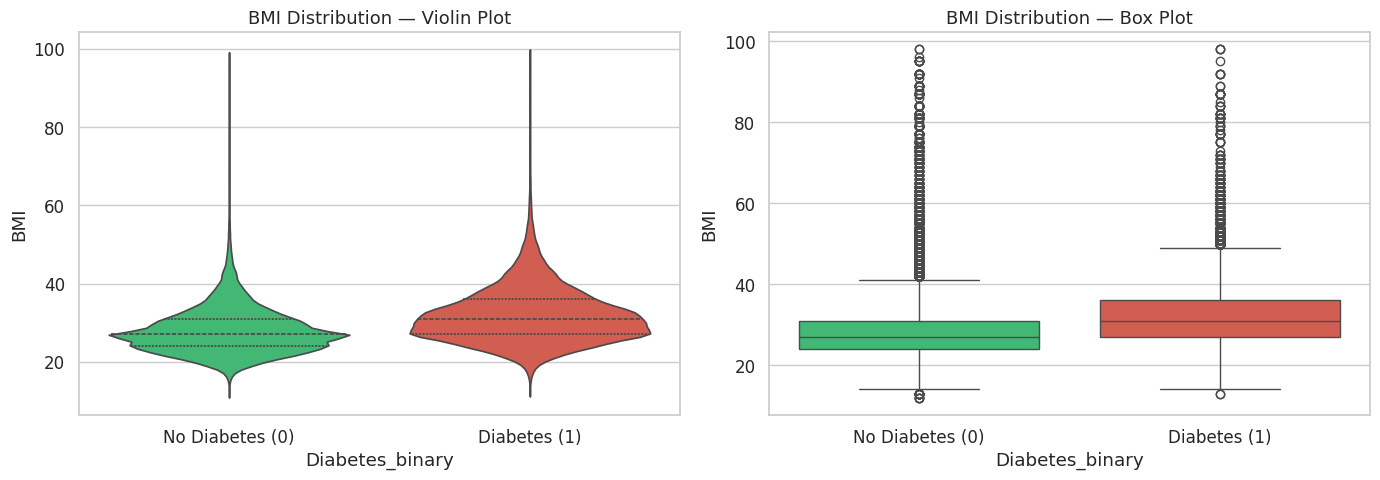

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=train_plot_df, x="Diabetes_binary", y="BMI",
    hue="Diabetes_binary", palette={0: colors[0], 1: colors[1]},
    inner="quartile", legend=False, ax=ax1
)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])
ax1.set_title("BMI Distribution — Violin Plot", fontsize=13)

sns.boxplot(
    data=train_plot_df, x="Diabetes_binary", y="BMI",
    hue="Diabetes_binary", palette={0: colors[0], 1: colors[1]},
    legend=False, ax=ax2
)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])
ax2.set_title("BMI Distribution — Box Plot", fontsize=13)

plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "bmi_by_class.png"), dpi=150)
plt.show()

### 7f. Bar Plots — Binary Features by Diabetes Status

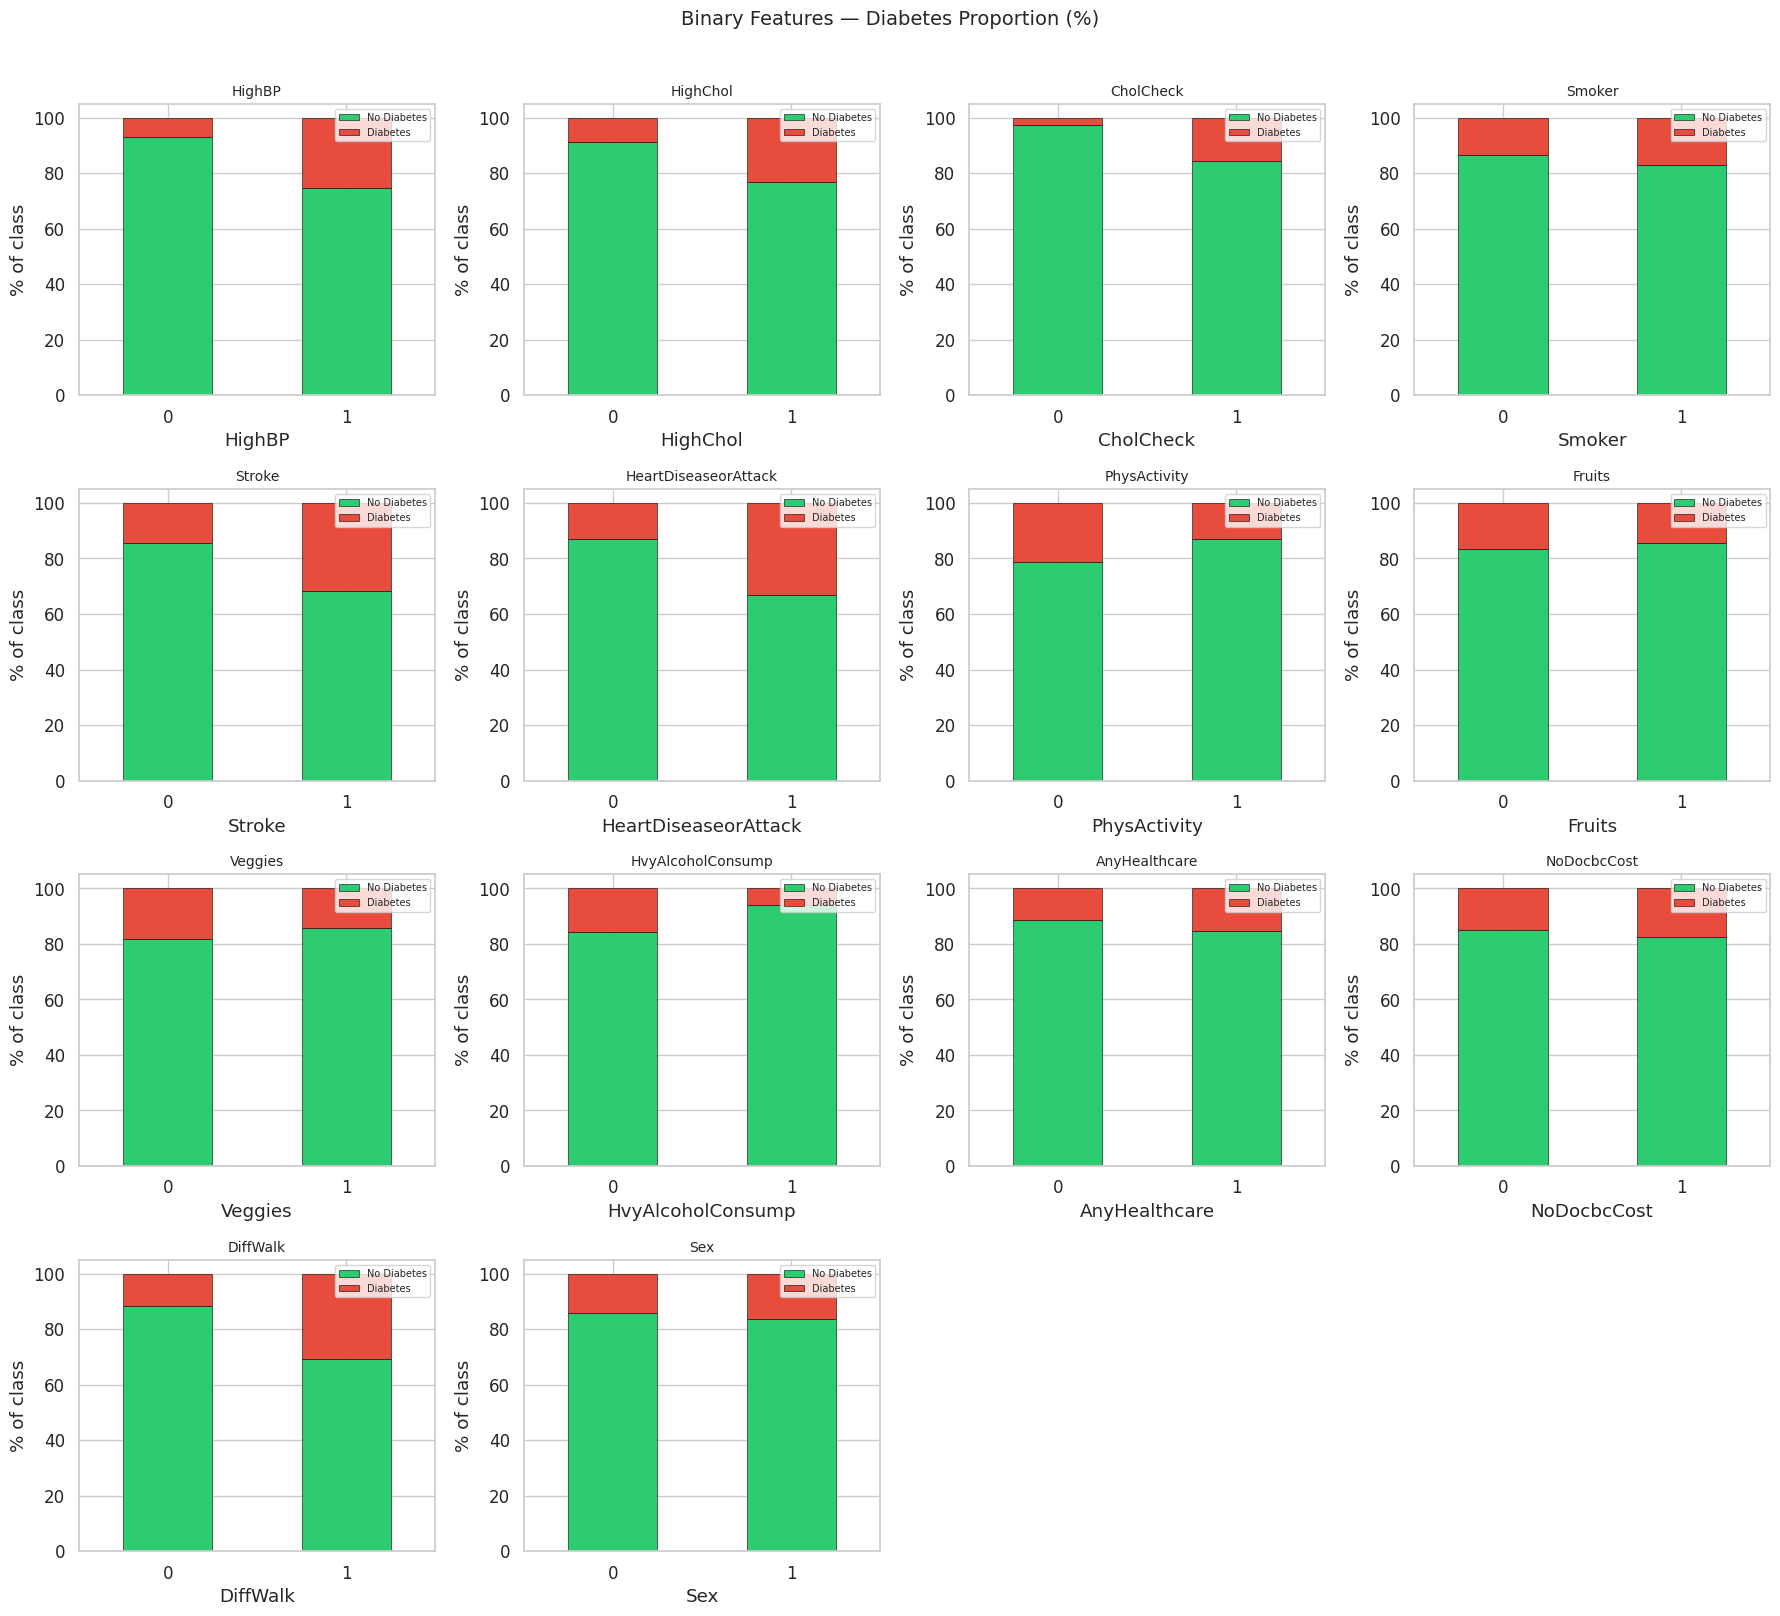

In [ ]:
n_bin = len(binary_cols)
n_cols_bar = 4
n_rows_bar = int(np.ceil(n_bin / n_cols_bar))
fig, axes = plt.subplots(n_rows_bar, n_cols_bar, figsize=(18, 4 * n_rows_bar))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    ct = pd.crosstab(train_plot_df[col], train_plot_df["Diabetes_binary"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=colors, edgecolor="black", linewidth=0.4)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("% of class")
    axes[i].set_xticklabels(["0", "1"], rotation=0)
    axes[i].legend(["No Diabetes", "Diabetes"], fontsize=7, loc="upper right")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Binary Features — Diabetes Proportion (%)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "binary_features_barplot.png"), dpi=150)
plt.show()

*   **What it shows**: This plot shows the **proportion of diabetes status (0 or 1) for each category of a given binary feature**. In simpler terms, for people who *have* the feature (e.g., `HighBP` = 1) and people who *don't have* the feature (e.g., `HighBP` = 0), what percentage of them have diabetes?
*   **Value**: This plot directly indicates the **risk factor** associated with a specific feature. For example, if you look at 'HighBP', it shows that among people *without* high blood pressure, a small percentage have diabetes, while among people *with* high blood pressure, a significantly higher percentage have diabetes. This helps identify features that increase the likelihood of diabetes.

In the binary classes that we've, that barplot reveal the risk factor, in HighBP binary feature we can see that among the person who doesn't have a HighBP there is only 8% who have diabetes and for the persons who have HighBP there is 25 % chance of diabetes, which reveal a risk factor that HighBP is an important risk factor  

---



---



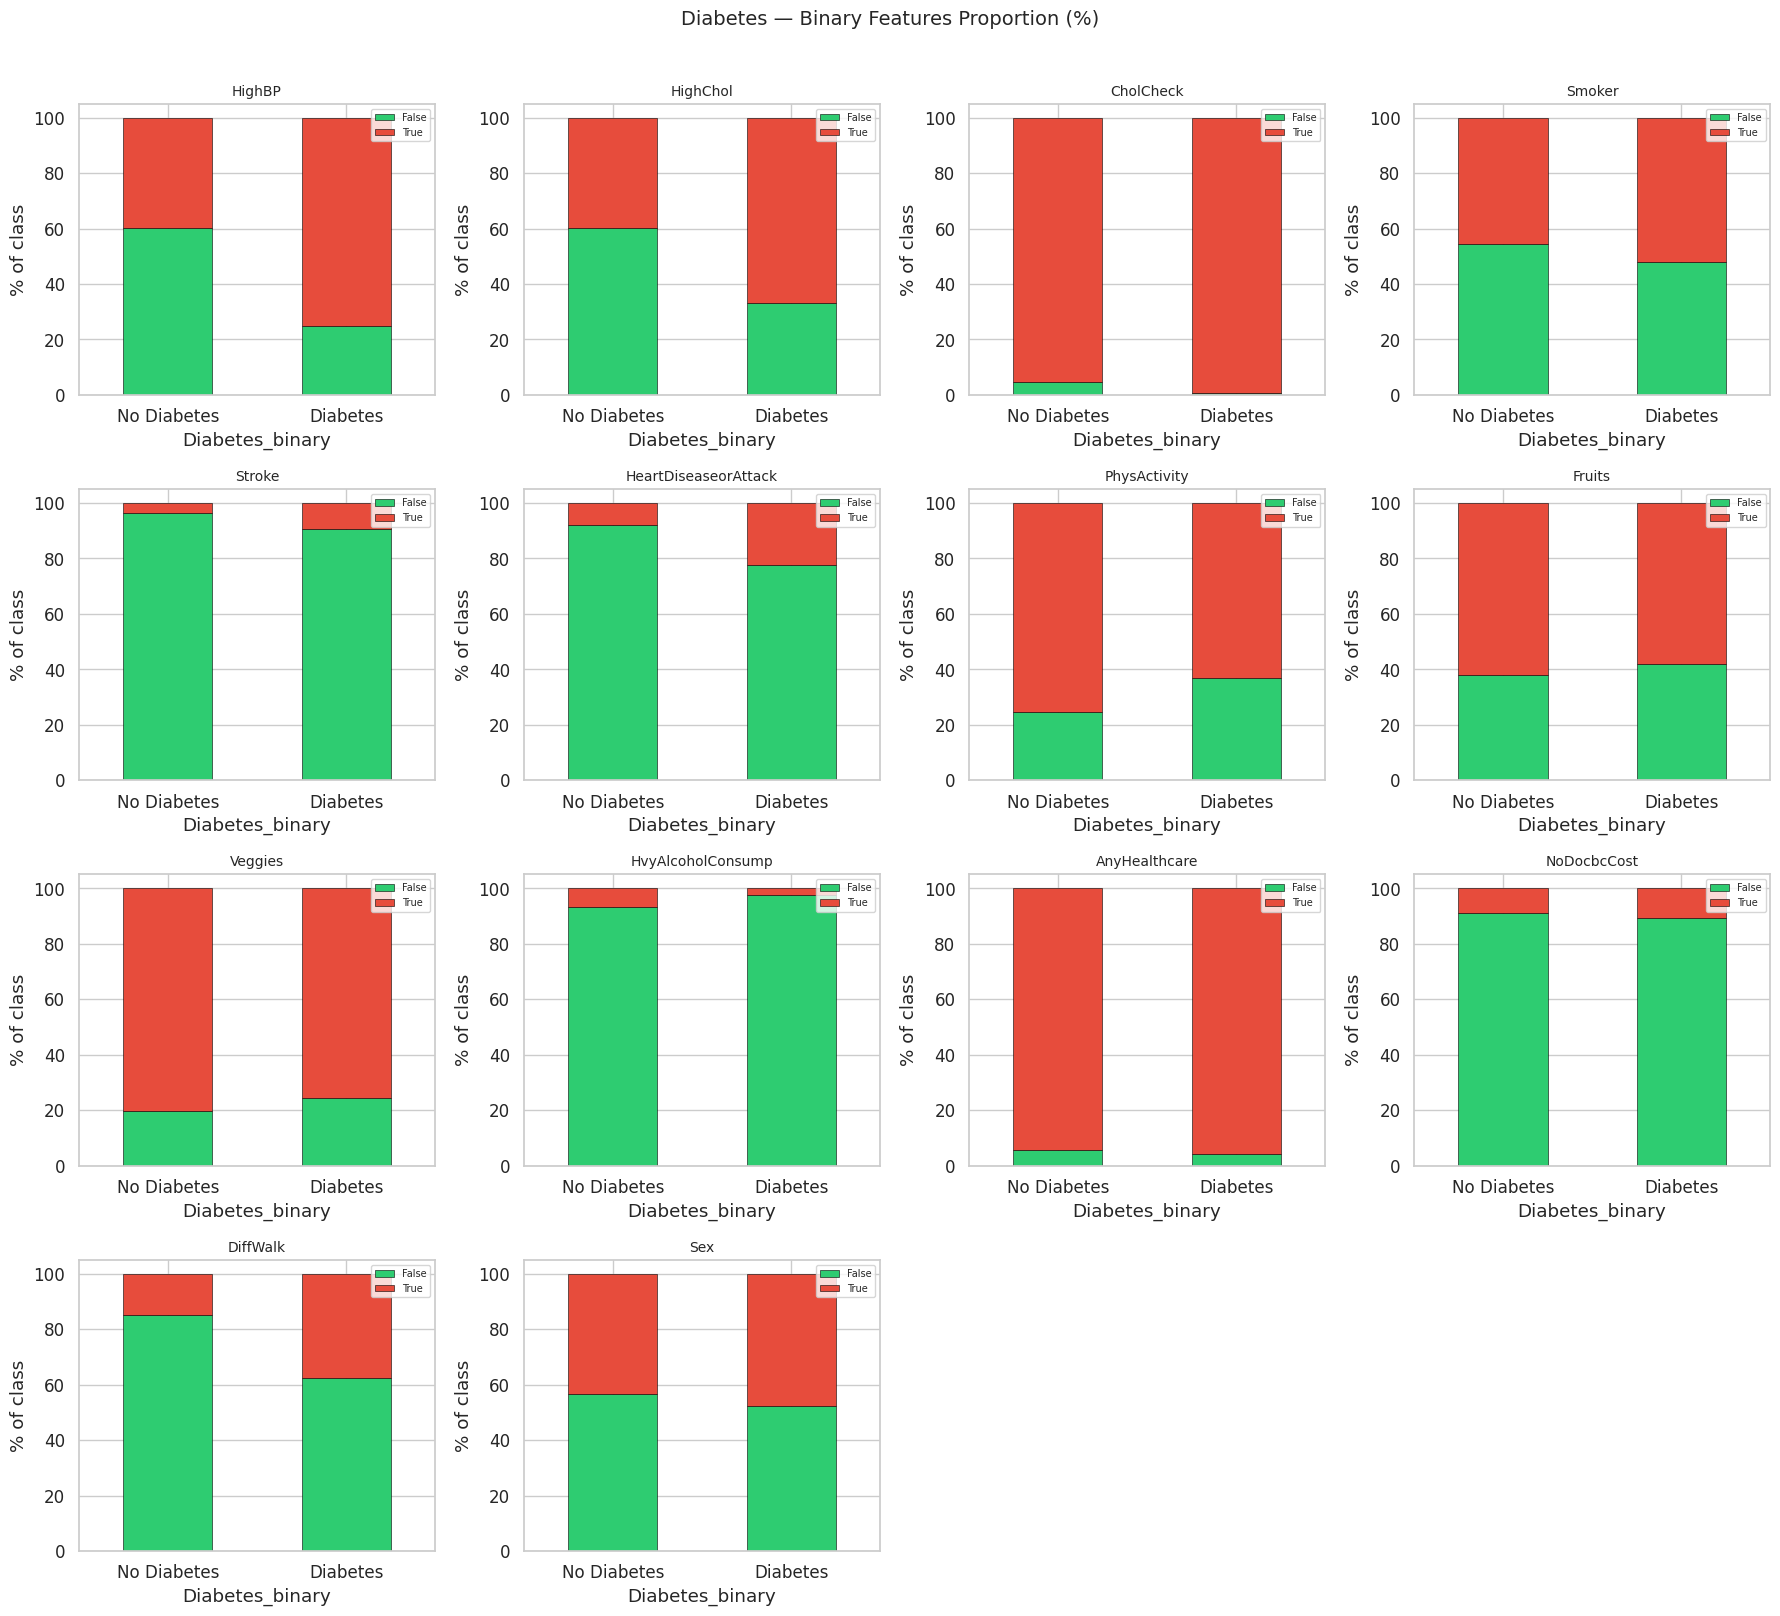

In [ ]:
n_bin = len(binary_cols)
n_cols_bar = 4
n_rows_bar = int(np.ceil(n_bin / n_cols_bar))
fig, axes = plt.subplots(n_rows_bar, n_cols_bar, figsize=(18, 4 * n_rows_bar))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    ct = pd.crosstab(train_plot_df["Diabetes_binary"], train_plot_df[col], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=colors, edgecolor="black", linewidth=0.4)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("% of class")
    axes[i].set_xticklabels(["No Diabetes", "Diabetes"], rotation=0)
    axes[i].legend(["False","True"], fontsize=7, loc="upper right")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Diabetes — Binary Features Proportion (%)", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "binary_features_barplot.png"), dpi=150)
plt.show()

*   **What it shows**: This plot shows the **proportion of a given binary feature (0 or 1) for each diabetes status**. In other words, among people who *do not have diabetes* (`Diabetes_binary` = 0) and among people who *have diabetes* (`Diabetes_binary` = 1), what percentage possess a specific feature?
*   **Value**: This plot helps understand the **characteristics or prevalence of features within the diabetic and non-diabetic populations**. For example, looking at 'HighBP', it might show that a higher percentage of people with diabetes have high blood pressure compared to people without diabetes. This is useful for characterizing the groups but doesn't directly tell you the *risk* of developing diabetes if you have high blood pressure (that's what the first plot does).

From this graph we can clearly see HighCol, and HighBP as the top features that differentiate the Diabetic and Non-Diabetic Classes. With Clear indications that AnyHealthcare, Veggies, Sex, Fruits, and NoDocBcCost may not be good differentiators between the Diabetics and Non-Diabetics.

---
## Step 8 — Selection and Implementation of a Normalization Method

**Objective:** Set variables to the same scale to ensure convergence of Deep Learning algorithms that are sensitive to orders of magnitude.

**Methods considered:** StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

**Decision:** Choice based on data distribution and model sensitivity.

**Justification:** Improve the robustness and fairness of the model.

In [ ]:
# Only scale continuous and ordinal columns (not binary 0/1 features)
cols_to_scale = continuous_cols + ordinal_cols
print(f"Columns to scale ({len(cols_to_scale)}): {cols_to_scale}")
print(f"Binary columns kept as-is ({len(binary_cols)}): {binary_cols}")

Columns to scale (7): ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age', 'Education', 'Income']
Binary columns kept as-is (14): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']


In [ ]:
# Compare scalers on training data
print("📊 Comparing normalization methods on training data:\n")
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler":   MinMaxScaler(),
    "RobustScaler":   RobustScaler(),
    "MaxAbsScaler":   MaxAbsScaler(),
}

comparison_results = {}
for name, scaler in scalers.items():
    scaled = scaler.fit_transform(X_train[cols_to_scale])
    scaled_df = pd.DataFrame(scaled, columns=cols_to_scale)

    result = {
        "mean_range":   (scaled_df.max() - scaled_df.min()).mean(),
        "mean_std":     scaled_df.std().mean(),
        "outlier_pct":  ((scaled_df.abs() > 3).sum().sum() / scaled_df.size * 100),
    }
    comparison_results[name] = result
    print(f"{name}:")
    print(f"  Mean range:        {result['mean_range']:.3f}")
    print(f"  Mean std:          {result['mean_std']:.3f}")
    print(f"  Outlier % (|z|>3): {result['outlier_pct']:.2f}%\n")

📊 Comparing normalization methods on training data:

StandardScaler:
  Mean range:        5.139
  Mean std:          1.000
  Outlier % (|z|>3): 1.22%

MinMaxScaler:
  Mean range:        1.000
  Mean std:          0.237
  Outlier % (|z|>3): 0.00%

RobustScaler:
  Mean range:        6.440
  Mean std:          1.425
  Outlier % (|z|>3): 4.37%

MaxAbsScaler:
  Mean range:        0.901
  Mean std:          0.215
  Outlier % (|z|>3): 0.00%



### Decision: RobustScaler

**Justification:**
- **BMI, MentHlth, PhysHlth** contain significant outliers (visible in boxplots)
- RobustScaler uses **median and IQR** (interquartile range) instead of mean and std
- This makes it **resistant to outliers** while preserving relative relationships
- Deep Learning models (gradient-based) benefit from scaled inputs not distorted by extreme values
- Ensures **fairness**: outlier patients don't disproportionately affect learned representations

In [ ]:
# Apply RobustScaler — fit on train only, transform both
chosen_scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = chosen_scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = chosen_scaler.transform(X_test[cols_to_scale])

print("✅ RobustScaler fitted on training set, applied to both sets")
print(f"\nScaled training data statistics:")
X_train_scaled[cols_to_scale].describe().round(3)

✅ RobustScaler fitted on training set, applied to both sets

Scaled training data statistics:


,BMI,MentHlth,PhysHlth,GenHlth,Age,Education,Income
count,185446.000,185446.000,185446.000,185446.000,185446.000,185446.000,185446.000
mean,0.207,1.741,1.161,-0.406,0.021,-0.007,-0.033
std,0.845,3.846,2.256,1.065,0.772,0.496,0.697
min,-1.875,0.000,0.000,-2.000,-1.750,-2.000,-1.667
25%,-0.375,0.000,0.000,-1.000,-0.500,-0.500,-0.333
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.625,1.000,1.000,0.000,0.500,0.500,0.667
max,8.875,15.000,7.500,2.000,1.250,0.500,0.667


---
## Step 9 — Saving of the Cleaned Dataset

**Objective:** Facilitate project reproducibility and versioning.

**Ethical and technical justification:** Ensures traceability, reproducibility of results, and a clear checkpoint in the development pipeline.

In [ ]:
# Save train/test splits (unscaled)
X_train.to_csv(os.path.join(OUTPUT_DIR, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(OUTPUT_DIR, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(OUTPUT_DIR, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(OUTPUT_DIR, "y_test.csv"), index=False)

# Save scaled versions
X_train_scaled.to_csv(os.path.join(OUTPUT_DIR, "X_train_scaled.csv"), index=False)
X_test_scaled.to_csv(os.path.join(OUTPUT_DIR, "X_test_scaled.csv"), index=False)

# Save scaler for reproducibility
with open(os.path.join(OUTPUT_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(chosen_scaler, f)

# Save everything as .pkl for fast reloading
data_dict = {
    "X_train": X_train, "X_test": X_test,
    "y_train": y_train, "y_test": y_test,
    "X_train_scaled": X_train_scaled,
    "X_test_scaled": X_test_scaled,
    "scaler": chosen_scaler,
    "binary_cols": binary_cols,
    "ordinal_cols": ordinal_cols,
    "continuous_cols": continuous_cols,
    "cols_to_scale": cols_to_scale,
}
with open(os.path.join(OUTPUT_DIR, "preprocessed_data.pkl"), "wb") as f:
    pickle.dump(data_dict, f)

print("✅ All outputs saved to 'output/' directory:")
print(f"   • X_train.csv          ({X_train.shape})")
print(f"   • X_test.csv           ({X_test.shape})")
print(f"   • y_train.csv          ({y_train.shape})")
print(f"   • y_test.csv           ({y_test.shape})")
print(f"   • X_train_scaled.csv   ({X_train_scaled.shape})")
print(f"   • X_test_scaled.csv    ({X_test_scaled.shape})")
print(f"   • scaler.pkl           (RobustScaler)")
print(f"   • preprocessed_data.pkl")

✅ All outputs saved to 'output/' directory:
   • X_train.csv          ((185446, 21))
   • X_test.csv           ((50736, 21))
   • y_train.csv          ((185446,))
   • y_test.csv           ((50736,))
   • X_train_scaled.csv   ((185446, 21))
   • X_test_scaled.csv    ((50736, 21))
   • scaler.pkl           (RobustScaler)
   • preprocessed_data.pkl


## Saving the cleanest dataset


In [ ]:
processed_X = pd.concat([X_train_scaled, X_test_scaled], axis=0).reset_index(drop=True)
processed_y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)
processed_X.to_csv("processed_X.csv", index=False)
processed_y.to_csv("processed_y.csv", index=False)
print(f"\n✅ Final processed data saved to root directory:")
print(f"   • processed_X.csv  ({processed_X.shape})")
print(f"   • processed_y.csv  ({processed_y.shape})")



✅ Final processed data saved to root directory:
   • processed_X.csv  ((236182, 21))
   • processed_y.csv  ((236182,))


---
## Summary

| Metric | Value |
|--------|-------|
| Original samples | 253,680 |
| Features | 21 |
| Binary features | 14 |
| Ordinal features | 4 (GenHlth, Age, Education, Income) |
| Continuous features | 3 (BMI, MentHlth, PhysHlth) |
| Missing values | 0 |
| Train/Test split | 80% / 20% (stratified) |
| Normalization | RobustScaler (fit on train only) |

### Statistical Tests Summary
- **Pearson**: All continuous/ordinal features show significant correlation with target (p < 0.001)
- **Levene**: Variance heterogeneity detected for most features → supports use of robust methods
- **ANOVA**: All features show significant inter-group differences (p < 0.05)

### Normalization Choice: RobustScaler
- Uses median and IQR instead of mean and std
- Resistant to outliers in BMI, MentHlth, PhysHlth
- Only applied to non-binary features
- Fitted on training set only → prevents data leakage